In [ ]:
  import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, regularizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
# from google.colab import drive
from sklearn.model_selection import train_test_split
from PIL import Image, ExifTags

In [ ]:
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

dataset_path = 'C:/Users/nisri/Downloads/capstone/sigma-onion-sensor/analyzeAI/Training_ov5'

Found 360 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


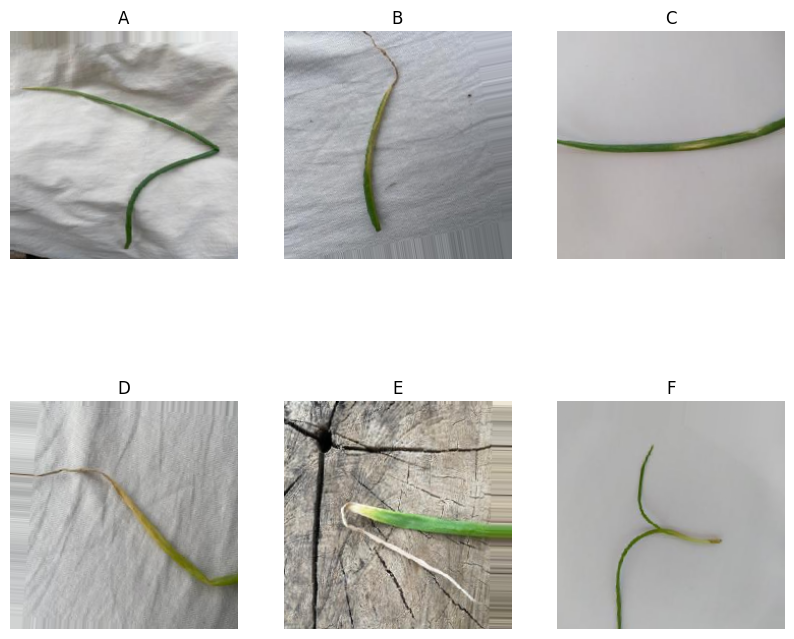

Class indices for training data: {'healthy': 0, 'moler': 1, 'purple blotch': 2}
Class indices for validation data: {'healthy': 0, 'moler': 1, 'purple blotch': 2}


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Define the class labels
class_labels = ['healthy', 'purple blotch', 'moler']
num_classes = len(class_labels)

# Image Data Generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)


validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Generate training and validation batches from directories
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)


import matplotlib.pyplot as plt

# Fetch a batch of images
x_batch, y_batch = next(train_generator)

# Function to plot images
def plot_images(images, labels):
    alphabet_labels = ['A', 'B', 'C', 'D', 'E', 'F']  # Alphabet labels for the images
    plt.figure(figsize=(10, 8))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        plt.title(f'{alphabet_labels[i]}')  # Show alphabets as titles above each image
        plt.axis("off")
    plt.subplots_adjust(hspace=0.5)  # Adjust horizontal space between images
    plt.show()

# Call the function with the first batch
plot_images(x_batch, y_batch)



# Print class indices to ensure consistent label mapping
print("Class indices for training data:", train_generator.class_indices)
print("Class indices for validation data:", validation_generator.class_indices)


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 64)        0

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model using the data generators
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)

Epoch 1/50
12/12 [==============================] - 96s 7s/step - loss: 1.2499 - accuracy: 0.3417 - val_loss: 1.0445 - val_accuracy: 0.3333
Epoch 2/50
12/12 [==============================] - 42s 3s/step - loss: 1.0344 - accuracy: 0.4833 - val_loss: 1.1327 - val_accuracy: 0.3222
Epoch 3/50
12/12 [==============================] - 45s 4s/step - loss: 0.9415 - accuracy: 0.5389 - val_loss: 1.0617 - val_accuracy: 0.3667
Epoch 4/50
12/12 [==============================] - 44s 4s/step - loss: 0.7974 - accuracy: 0.6472 - val_loss: 1.0813 - val_accuracy: 0.3444
Epoch 5/50
12/12 [==============================] - 41s 3s/step - loss: 0.7240 - accuracy: 0.6694 - val_loss: 1.2633 - val_accuracy: 0.3889
Epoch 6/50
12/12 [==============================] - 44s 3s/step - loss: 0.7469 - accuracy: 0.7083 - val_loss: 1.1249 - val_accuracy: 0.3778
Epoch 7/50
12/12 [==============================] - 44s 4s/step - loss: 0.6565 - accuracy: 0.7194 - val_loss: 1.1949 - val_accuracy: 0.4667
Epoch 8/50
12/12 [==

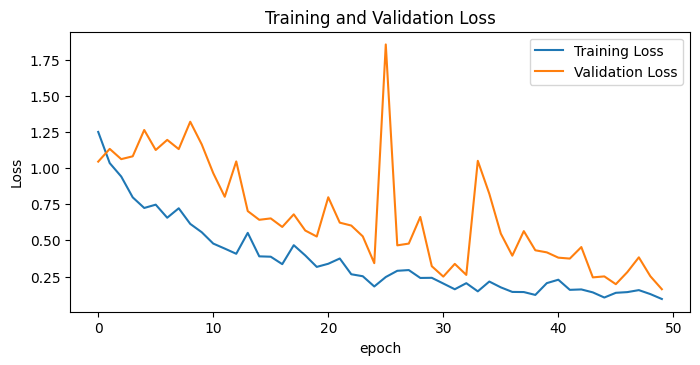

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

1/1 [==============================] - 1s 1s/step


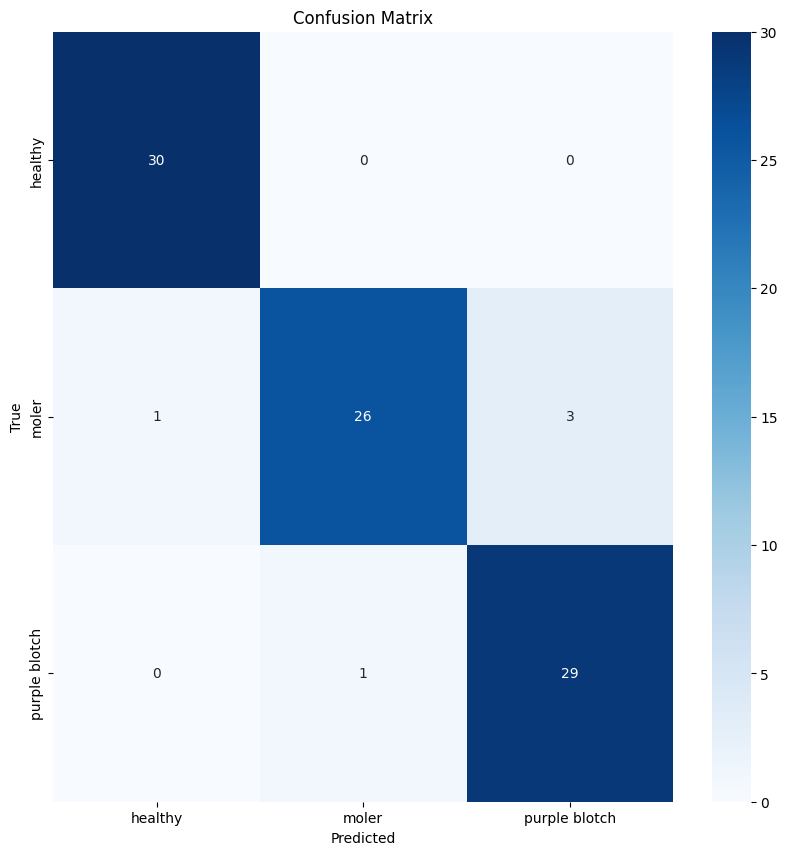

               precision    recall  f1-score   support

      healthy       0.97      1.00      0.98        30
        moler       0.96      0.87      0.91        30
purple blotch       0.91      0.97      0.94        30

     accuracy                           0.94        90
    macro avg       0.95      0.94      0.94        90
 weighted avg       0.95      0.94      0.94        90

validation Loss: 0.1621
 Accuracy: 94.44%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model on the test set
validation_loss, validation_accuracy = model.evaluate(validation_generator)

# Reset the validation generator
validation_generator.reset()

# Fetch and predict all images in the validation set
predictions = []
true_labels = []
for _ in range(len(validation_generator)):
    x_val, y_val = next(validation_generator)
    preds = model.predict(x_val)
    predictions.extend(np.argmax(preds, axis=1))
    true_labels.extend(y_val)

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predictions)
class_labels = list(validation_generator.class_indices.keys())

# Plot the confusion matrix
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print the classification report
print(classification_report(true_labels, predictions, target_names=class_labels))

print(f"validation Loss: {validation_loss:.4f}")
print(f" Accuracy: {validation_accuracy * 100:.2f}%")

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a test data generator, which only rescales the images
test_datagen = ImageDataGenerator(rescale=1./255)

# Generate batches of test images
test_generator = test_datagen.flow_from_directory(
    'C:/Users/nisri/Downloads/capstone/sigma-onion-sensor/analyzeAI/Testing_ov5',
    target_size=(224, 224),
    batch_size=32,  # Adjust the batch size according to your needs
    class_mode='sparse',  # Ensure the class mode matches the one used during training
    shuffle=False  # Do not shuffle the data for testing; it's important for matching outputs with labels
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)

# Predict all images in the test set for detailed classification report
test_generator.reset()  # Resetting generator to ensure correct label matching
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get the true labels from the generator
true_classes = test_generator.classes

# Print the classification report including F1 score, precision, and recall
print(classification_report(true_classes, predicted_classes, target_names=test_generator.class_indices.keys()))

# Print accuracy and loss
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Found 60 images belonging to 3 classes.
2/2 [==============================] - 2s 750ms/step
               precision    recall  f1-score   support

      healthy       0.89      0.40      0.55        20
        moler       0.65      0.85      0.74        20
purple blotch       0.60      0.75      0.67        20

     accuracy                           0.67        60
    macro avg       0.71      0.67      0.65        60
 weighted avg       0.71      0.67      0.65        60

Test Loss: 1.2966
Test Accuracy: 66.67%


In [ ]:
model.save('/content/drive/MyDrive/fix/ov5_modelbase.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
